# Alissa Beaderstadt Notebook
# P3: Text Exploration

REQ: Open notebooks with a standard header including a good title, your company/name/alias, a link to the repo, purpose, and date.

- Author: [Alissa Beaderstadt](https://github.com/abeaderstadt/)
- Repository: [nlp-03-text-exploration](https://github.com/abeaderstadt/nlp-03-text-exploration/)
- Date: 2026-03

Purpose

  Perform exploratory analysis of a small, controlled text corpus.
  Demonstrate how structure emerges from token distributions,
  category comparisons, and co-occurrence patterns.

Analytical Questions

- What tokens dominate each category (exposure, guidance, definition, regulatory)?
- How do categories differ in vocabulary?
- What words appear in similar contexts?
- What structure is visible before using any models?

Notes

- This module focuses on exploratory analysis (EDA), not modeling.
- Results here prepare for later work with pipelines and embeddings.
- Phase 5 uses a new corpus based on real-world text from a CDC/NIOSH document.

Project Instructions

- See [docs/project-instructions.md](../docs/project-instructions.md)
- See [docs/glossary.md](../docs/glossary.md)

## Terminology

In preparation for large language models and related methods, our analysis does not begin with semantic interpretation.
Instead, we focus on **proximity** and observable **patterns** in the text.

We evaluate **co-occurrence (context windows)**, 
that is, _which words tend to appear near each other_.

The full collection of text is called a **corpus** (a set of documents).
For this analysis, each document is represented as a single line of text.

See the README.md for more

This is a Markdown cell.

## Section 1. Setup and Imports

Imports and configuration appear once, at the top.

This is a Markdown cell.

In [245]:
# Section 1 Python cell

from collections import defaultdict
import logging
import os
from pathlib import Path

from datafun_toolkit.logger import get_logger, log_header, log_path
import matplotlib.pyplot as plt

os.environ["POLARS_SKIP_CPU_CHECK"] = "1"
import polars as pl

print("Imports complete.")

Imports complete.


### Configure Logger and Paths

This is a Markdown cell.

In [246]:
# Section 1 Python cell (logger configuration and path setup)

LOG: logging.Logger = get_logger("CI", level="DEBUG")

NOTEBOOKS_PATH: Path = Path.cwd()
ROOT_PATH: Path = NOTEBOOKS_PATH.parent
SCRIPTS_PATH: Path = ROOT_PATH / "scripts"

log_header(LOG, "MODULE 3 NOTEBOOK: CORPUS EXPLORATION")

log_path(LOG, "ROOT_PATH", ROOT_PATH)
log_path(LOG, "NOTEBOOKS_PATH", NOTEBOOKS_PATH)
log_path(LOG, "SCRIPTS_PATH", SCRIPTS_PATH)

LOG.info("Logger configured.")

2026-03-23 15:40:13 | INFO | CI | === RUN START ===
2026-03-23 15:40:13 | INFO | CI | project=MODULE 3 NOTEBOOK: CORPUS EXPLORATION
2026-03-23 15:40:13 | INFO | CI | repo_dir=nlp-03-text-exploration
2026-03-23 15:40:13 | INFO | CI | python=3.14.3
2026-03-23 15:40:13 | INFO | CI | os=Windows 11
2026-03-23 15:40:13 | INFO | CI | shell=powershell
2026-03-23 15:40:13 | INFO | CI | cwd=notebooks
2026-03-23 15:40:13 | INFO | CI | github_actions=False
2026-03-23 15:40:13 | INFO | CI | ROOT_PATH = .
2026-03-23 15:40:13 | INFO | CI | NOTEBOOKS_PATH = notebooks
2026-03-23 15:40:13 | INFO | CI | SCRIPTS_PATH = scripts
2026-03-23 15:40:13 | INFO | CI | Logger configured.


## Section 2. Define Corpus (Labeled Text Documents)

This is a Markdown cell.

In [247]:
# Section 2 Python cell

# A corpus is a collection of text documents.
# Each document is associated with a category label.
# Use a list of dictionaries to represent the corpus in memory.
# A dictionary uses labeled key:value pairs.
# Key:value pairs let us store the category and the text together.

corpus = [
    {
        "category": "exposure",
        "text": "Healthcare workers may be occupationally exposed to drugs.",
    },
    {
        "category": "exposure",
        "text": "Workers may experience adverse health effects as a result.",
    },
    {
        "category": "exposure",
        "text": "Occupational exposure to hazardous drugs can occur in healthcare settings.",
    },
    {
        "category": "guidance",
        "text": "The list assists employers in providing safe and healthy workplaces.",
    },
    {
        "category": "guidance",
        "text": "The document is advisory in nature and informational in content.",
    },
    {
        "category": "guidance",
        "text": "The list identifies drugs that are hazardous to workers.",
    },
    {
        "category": "definition",
        "text": "Hazardous drugs have intrinsic properties that meet the NIOSH definition.",
    },
    {
        "category": "definition",
        "text": "Drugs are determined by NIOSH to be hazardous.",
    },
    {
        "category": "definition",
        "text": "The list presents drugs considered hazardous to workers.",
    },
    {
        "category": "regulatory",
        "text": "The list includes drugs approved by the Food and Drug Administration.",
    },
    {
        "category": "regulatory",
        "text": "The FDA Center for Drug Evaluation and Research is referenced.",
    },
    {
        "category": "regulatory",
        "text": "NIOSH published updates to the list in multiple years.",
    },
]

print(f"Corpus contains {len(corpus)} documents.")

Corpus contains 12 documents.


## Section 3. Tokenize and Clean Text

This is a Markdown cell.

In [248]:
# Section 3 Python cell

# Tokenization splits text into word-like units.

# Define a function to tokenize text by lowercasing, splitting on whitespace,
# and stripping common punctuation. We also filter out very short tokens (length <= 2) and stopwords.
# This simple tokenizer is sufficient for our small, controlled corpus.
# Use the string strip() method to remove punctuation from the beginning and end of each token.
stopwords = {"the", "and", "is", "of", "to", "for", "are"}


def tokenize(text: str) -> list[str]:
    tokens = text.lower().split()
    return [
        t.strip(".,:;!?()[]\"'") for t in tokens if len(t) > 2 and t not in stopwords
    ]


# Define a new empty list to hold the token records we will create.
records_list: list[dict[str, str]] = []
# Loop through each document, tokenize the text,
# and create a record for each token with its category and
# add it to our list of records.
for doc in corpus:
    # Call our function to tokenize the text of the current document.
    tokens = tokenize(doc["text"])
    # Loop through each token produced by the tokenizer and
    # create a record that includes the category of the document and the token itself.
    # Append this record to our list of records.
    for token in tokens:
        records_list.append({"category": doc["category"], "token": token})

# Create a Polars DataFrame from the list of token records for easier analysis.
token_df: pl.DataFrame = pl.DataFrame(records_list)

# Show results
print("Tokenization complete.")
print(token_df.head(10))

Tokenization complete.
shape: (10, 2)
┌──────────┬────────────────┐
│ category ┆ token          │
│ ---      ┆ ---            │
│ str      ┆ str            │
╞══════════╪════════════════╡
│ exposure ┆ healthcare     │
│ exposure ┆ workers        │
│ exposure ┆ may            │
│ exposure ┆ occupationally │
│ exposure ┆ exposed        │
│ exposure ┆ drugs          │
│ exposure ┆ workers        │
│ exposure ┆ may            │
│ exposure ┆ experience     │
│ exposure ┆ adverse        │
└──────────┴────────────────┘


## Section 4. Compute Global Token Frequencies

This is a Markdown cell.

In [249]:
# Section 4 Python cell

# Frequency distribution = how often each token appears.

# Create a DataFrame that groups the tokens by their text and
# counts how many times each token appears across the entire corpus.
global_freq_df: pl.DataFrame = (
    token_df.group_by("token").len().sort("len", descending=True)
)

# Show results
print("Top global tokens:")
print(global_freq_df.head(10))

Top global tokens:
shape: (10, 2)
┌────────────┬─────┐
│ token      ┆ len │
│ ---        ┆ --- │
│ str        ┆ u32 │
╞════════════╪═════╡
│ drugs      ┆ 7   │
│ hazardous  ┆ 5   │
│ list       ┆ 5   │
│ workers    ┆ 4   │
│ niosh      ┆ 3   │
│ may        ┆ 2   │
│ drug       ┆ 2   │
│ that       ┆ 2   │
│ healthcare ┆ 2   │
│ years      ┆ 1   │
└────────────┴─────┘


## Section 5. Compute Token Frequencies by Category

This is a Markdown cell.

In [250]:
# Section 5 Python cell

# Compare token usage across categories.

# Create a new DataFrame that groups the tokens by both their category and text,
# counts how many times each token appears within each category,
# and sorts the results first by category and then by frequency in descending order.
# This shows which tokens are most common within each category.
category_freq_df: pl.DataFrame = (
    token_df.group_by(["category", "token"])
    .len()
    .sort(["category", "len"], descending=True)
)

# Show results
print("Top tokens by category:")
print(category_freq_df.head(20))

Top tokens by category:
shape: (20, 3)
┌────────────┬───────────┬─────┐
│ category   ┆ token     ┆ len │
│ ---        ┆ ---       ┆ --- │
│ str        ┆ str       ┆ u32 │
╞════════════╪═══════════╪═════╡
│ regulatory ┆ drug      ┆ 2   │
│ regulatory ┆ list      ┆ 2   │
│ regulatory ┆ updates   ┆ 1   │
│ regulatory ┆ multiple  ┆ 1   │
│ regulatory ┆ published ┆ 1   │
│ …          ┆ …         ┆ …   │
│ regulatory ┆ center    ┆ 1   │
│ regulatory ┆ drugs     ┆ 1   │
│ guidance   ┆ list      ┆ 2   │
│ guidance   ┆ providing ┆ 1   │
│ guidance   ┆ drugs     ┆ 1   │
└────────────┴───────────┴─────┘


## Section 6. Identify Top Tokens per Category

This is a Markdown cell.

In [251]:
# Section 6 Python cell

# Show top tokens per category.


# Define a new empty dictionary to store the top tokens for each category.
top_per_category_dict: dict[str, list[str]] = {}

# Loop through each unique category in the token DataFrame,
# filter the category frequency DataFrame to get the top 5 tokens for that category,
# and store the list of top tokens in the dictionary.
# Also, print the top tokens for each category.
for category in token_df["category"].unique().to_list():
    subset_df = category_freq_df.filter(pl.col("category") == category).head(5)
    top_tokens_list = subset_df["token"].to_list()
    top_per_category_dict[category] = top_tokens_list

    # Show results for this category
    print(f"{category.upper()} top tokens: {top_tokens_list}")

GUIDANCE top tokens: ['list', 'providing', 'drugs', 'document', 'nature']
REGULATORY top tokens: ['drug', 'list', 'updates', 'multiple', 'published']
DEFINITION top tokens: ['hazardous', 'drugs', 'niosh', 'that', 'definition']
EXPOSURE top tokens: ['drugs', 'workers', 'healthcare', 'may', 'health']


## Section 7. Analyze Co-occurrence (Context Windows)

This is a Markdown cell.

In [252]:
# Section 7 Python cell

# Co-occurrence examines which tokens appear near each other.

# Define how many tokens on each side of a target token we include as context.
# A window size of 2 means:
#   - up to 2 tokens before the target token
#   - up to 2 tokens after the target token
# The target token itself is not included in its context list.
WINDOW_SIZE: int = 3

# Define a new empty dictionary to store the co-occurrence information.
# The keys will be target tokens,
# and the values will be lists of context tokens that appear near the target token.
co_occurrence_dict: dict[str, list[str]] = defaultdict(list)

# Loop through each document in the corpus, tokenize the text,
# and for each token, determine its context tokens based on the defined window size.
for doc in corpus:
    tokens = tokenize(doc["text"])
    for i, token in enumerate(tokens):
        start = max(0, i - WINDOW_SIZE)
        end = min(len(tokens), i + WINDOW_SIZE + 1)
        context = tokens[start:end]
        for ctx in context:
            if ctx != token:
                co_occurrence_dict[token].append(ctx)

# Show results
for target in ["hazardous", "drugs", "workers", "exposure"]:
    print(f"\nContext for '{target}':")
    print(co_occurrence_dict[target][:10])


Context for 'hazardous':
['occupational', 'exposure', 'drugs', 'can', 'occur', 'identifies', 'drugs', 'that', 'workers', 'drugs']

Context for 'drugs':
['may', 'occupationally', 'exposed', 'occupational', 'exposure', 'hazardous', 'can', 'occur', 'healthcare', 'list']

Context for 'workers':
['healthcare', 'may', 'occupationally', 'exposed', 'may', 'experience', 'adverse', 'drugs', 'that', 'hazardous']

Context for 'exposure':
['occupational', 'hazardous', 'drugs', 'can']


## Section 8. Create Bigrams (Local Word Pairs) and Compute Frequencies

This is a Markdown cell.

In [253]:
# Section 8 Python cell

# Bigrams combine each word with the next word in the text.
# This helps us capture local structure: how words are used together,
# not just which words appear individually.

# Bigrams capture pairs of consecutive tokens.

# Define a new empty list to hold the bigram tuples we will create.
bigrams_list: list[tuple[str, str]] = []

# Loop through each document in the corpus, tokenize the text,
# and create bigrams by pairing each token with the next token in the list.
for doc in corpus:
    tokens = tokenize(doc["text"])
    for i in range(len(tokens) - 1):
        bigrams_list.append((tokens[i], tokens[i + 1]))

# Create a DataFrame from the list of bigram tuples,
# where each bigram is represented as a single string with the two tokens separated by a space.
bigram_df: pl.DataFrame = pl.DataFrame(
    {"bigram": [f"{a} {b}" for a, b in bigrams_list]}
)

# Create a new DataFrame that groups the bigrams by their text
# and counts how many times each bigram appears,
# then sorts the results by frequency in descending order.
bigram_freq_df: pl.DataFrame = (
    bigram_df.group_by("bigram").len().sort("len", descending=True)
)

# Show results
print("Top bigrams:")
print(bigram_freq_df.head(10))

Top bigrams:
shape: (10, 2)
┌────────────────────┬─────┐
│ bigram             ┆ len │
│ ---                ┆ --- │
│ str                ┆ u32 │
╞════════════════════╪═════╡
│ workers may        ┆ 2   │
│ hazardous workers  ┆ 2   │
│ hazardous drugs    ┆ 2   │
│ adverse health     ┆ 1   │
│ list identifies    ┆ 1   │
│ list multiple      ┆ 1   │
│ list includes      ┆ 1   │
│ assists employers  ┆ 1   │
│ exposure hazardous ┆ 1   │
│ approved food      ┆ 1   │
└────────────────────┴─────┘


## Section 9. Visualize Token Frequencies

This is a Markdown cell.



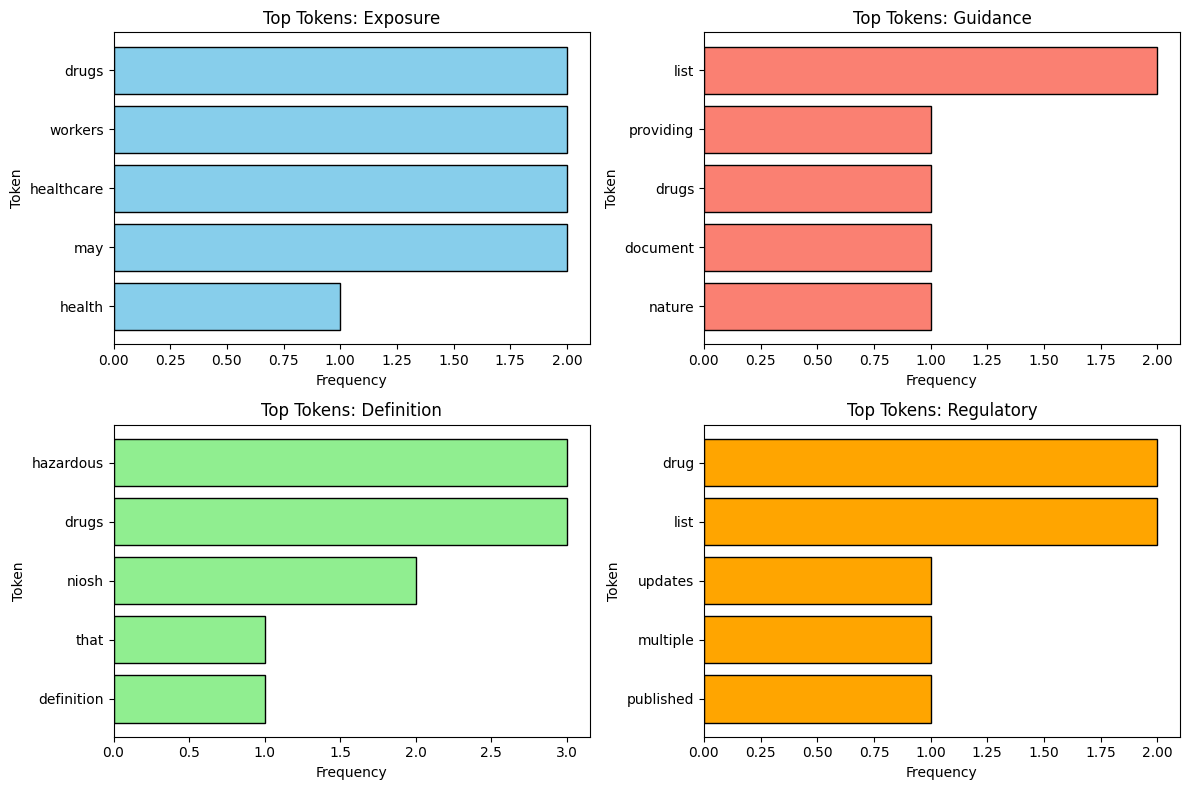

In [254]:
# List of categories and colors for each
categories = ["exposure", "guidance", "definition", "regulatory"]
colors = ["skyblue", "salmon", "lightgreen", "orange"]

# Create a 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()  # Flatten to easily index subplots

for i, category in enumerate(categories):
    # Filter top 5 tokens for this category
    top_df = category_freq_df.filter(pl.col("category") == category).head(5)

    # Horizontal bar chart with category-specific color
    axes[i].barh(top_df["token"], top_df["len"], color=colors[i], edgecolor="black")

    # Invert y-axis so highest frequency is on top
    axes[i].invert_yaxis()

    # Set titles and labels
    axes[i].set_title(f"Top Tokens: {category.capitalize()}")
    axes[i].set_xlabel("Frequency")
    axes[i].set_ylabel("Token")

# Adjust layout so subplots don't overlap
plt.tight_layout()
plt.show()

## Section 10. Interpret Results and Identify Patterns

This is a Markdown cell.

In [255]:
# Section 10 Python cell

print("\nBEADERSTADT SPECIFIC OBSERVATIONS:")

print(
    "- The most frequent tokens include words like 'hazardous', 'drugs', and 'workers', which makes sense for this domain."
)
print(
    "- After removing stopwords, the bigrams became much more meaningful, showing phrases like 'hazardous drugs' and 'healthcare workers'."
)
print(
    "- Some overlap exists between categories, especially with terms like 'drug' and 'drugs', but each category still has its own dominant vocabulary."
)
print(
    "- Using horizontal bar charts for each category makes it easy to quickly compare and see that while some terms overlap, categories remain distinct."
)
print(
    "- Co-occurrence results show that words like 'hazardous' and 'drugs' appear in similar contexts, reinforcing their relationship."
)


BEADERSTADT SPECIFIC OBSERVATIONS:
- The most frequent tokens include words like 'hazardous', 'drugs', and 'workers', which makes sense for this domain.
- After removing stopwords, the bigrams became much more meaningful, showing phrases like 'hazardous drugs' and 'healthcare workers'.
- Some overlap exists between categories, especially with terms like 'drug' and 'drugs', but each category still has its own dominant vocabulary.
- Using horizontal bar charts for each category makes it easy to quickly compare and see that while some terms overlap, categories remain distinct.
- Co-occurrence results show that words like 'hazardous' and 'drugs' appear in similar contexts, reinforcing their relationship.


In [256]:
# Final Python cell

LOG.info("========================")
LOG.info("Notebook executed successfully!")
LOG.info("========================")

print("Notebook executed successfully.")

2026-03-23 15:40:14 | INFO | CI | ========================
2026-03-23 15:40:14 | INFO | CI | Notebook executed successfully!
2026-03-23 15:40:14 | INFO | CI | ========================


Notebook executed successfully.
